# Meeting Notes: 3/11/2026
- Write explanations of your code
    - Use textcells and add section/subsection names
- Your project is using ML algorithms
    - Use more ML algorithms
        - Decision Tree
        - XGBoost
        - RNN
        - LSTM
    - Use more hyperparameter of ML algorithms
- Use my book for ML algorithms: https://datasmp.github.io/intro_ml/intro_ml.html


In [11]:
# Environment preflight check for reproducibility
import importlib.util

required_core = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'yfinance': 'yfinance',
    'sklearn': 'scikit-learn',
    'xgboost': 'xgboost',
}

missing_core = [pkg for mod, pkg in required_core.items() if importlib.util.find_spec(mod) is None]
if missing_core:
    print('Missing core packages:', missing_core)
    print('Install with: pip install ' + ' '.join(missing_core))
    raise ImportError('Install missing core packages, then rerun this notebook from Cell 2.')
else:
    print('Core package check passed.')

HAS_TF = importlib.util.find_spec('tensorflow') is not None
if HAS_TF:
    print('Optional package available: tensorflow (RNN/LSTM cells will run).')
else:
    print('Optional package missing: tensorflow (RNN/LSTM cells will be skipped).')

Core package check passed.
Optional package available: tensorflow (RNN/LSTM cells will run).


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

import warnings
warnings.filterwarnings("ignore")

STOCK_DICT = {'Apple': 'AAPL', 'Tesla': 'TSLA', 'Amazon': 'AMZN', 'Visa': 'V', 'Microsoft': 'MSFT'}
START = '2017-1-1'
END = '2019-12-31'
CACHE_FILE = Path('prices_cache.csv')

# Cell 2: Raw data only (no cleaning) + single combined preview output
if CACHE_FILE.exists():
    raw_df = pd.read_csv(CACHE_FILE)
else:
    symbol_to_name = {v: k for k, v in STOCK_DICT.items()}
    downloaded = yf.download(
        tickers=list(STOCK_DICT.values()),
        start=START,
        end=END,
        progress=False,
        auto_adjust=False
    )['Close']

    raw_df = downloaded.rename(columns=symbol_to_name).reset_index()
    raw_df.to_csv(CACHE_FILE, index=False)

# Keep consistent column order
raw_df = raw_df[['Date'] + list(STOCK_DICT.keys())]

# Single output section: raw data + raw datetime/time preview
raw_preview = raw_df.head(5).copy()
raw_preview['Raw_DateTime'] = pd.to_datetime(raw_preview['Date'], errors='coerce')
raw_preview['Time_Component'] = raw_preview['Raw_DateTime'].dt.strftime('%H:%M:%S').fillna('Invalid')
raw_preview

,Date,Apple,Tesla,Amazon,Visa,Microsoft,Raw_DateTime,Time_Component
0,2017-01-03,29.037500,37.683498,62.580002,14.466000,79.500000,2017-01-03,00:00:00
1,2017-01-04,29.004999,37.859001,62.299999,15.132667,80.150002,2017-01-04,00:00:00
2,2017-01-05,29.152500,39.022499,62.299999,15.116667,81.089996,2017-01-05,00:00:00
3,2017-01-06,29.477501,39.799500,62.840000,15.267333,82.209999,2017-01-06,00:00:00
4,2017-01-09,29.747499,39.846001,62.639999,15.418667,81.750000,2017-01-09,00:00:00


In [3]:
# Cell 3: Cleaning pipeline applied to raw_df
df = raw_df.copy()

# Parse Date column and remove rows where date is invalid
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

# Remove time part from Date and use Date as index
df['Date'] = df['Date'].dt.normalize()
df = df.drop_duplicates(subset=['Date'], keep='first')
df = df.sort_values('Date')
df = df.set_index('Date')

# Ensure price columns are numeric and drop incomplete rows
for col in STOCK_DICT.keys():
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(how='any')

df.head()

,Apple,Tesla,Amazon,Visa,Microsoft
Date,,,,,
2017-01-03,29.037500,37.683498,62.580002,14.466000,79.500000
2017-01-04,29.004999,37.859001,62.299999,15.132667,80.150002
2017-01-05,29.152500,39.022499,62.299999,15.116667,81.089996
2017-01-06,29.477501,39.799500,62.840000,15.267333,82.209999
2017-01-09,29.747499,39.846001,62.639999,15.418667,81.750000


In [8]:
# log return = log(today) - log(yesterday) = log(today/yesterday)
df_logreturn = np.log(df/df.shift(1))
df_logreturn.dropna(inplace=True)
df_logreturn.head()

,Apple,Tesla,Amazon,Visa,Microsoft
Date,,,,,
2017-01-04,-0.001120,0.004646,-0.004484,0.045055,0.008143
2017-01-05,0.005072,0.030270,0.000000,-0.001058,0.011660
2017-01-06,0.011087,0.019716,0.008630,0.009918,0.013717
2017-01-09,0.009118,0.001168,-0.003188,0.009863,-0.005611
2017-01-10,0.001008,-0.001281,-0.000319,-0.006115,-0.005397


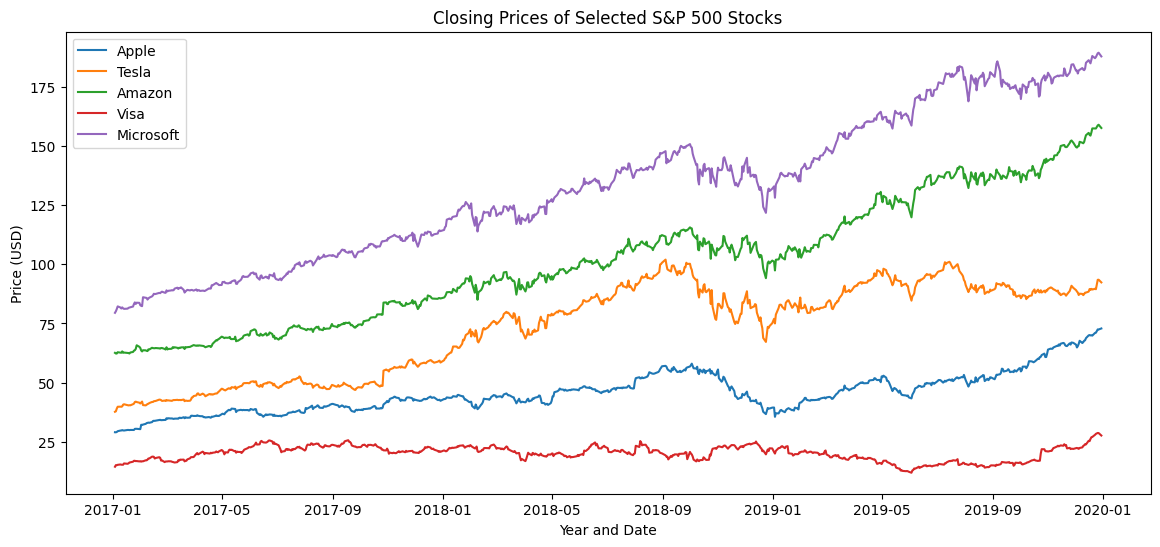

In [9]:
plt.figure(figsize=(14,6))
for col in df.columns:
    plt.plot(df[col], label=col)

plt.title("Closing Prices of Selected S&P 500 Stocks")
plt.xlabel("Year and Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [44]:
import pandas as pd

# Custom S&P-like data for my 5 stocks
data = {
    'Symbol': ['AAPL','TSLA','AMZN','V','MSFT'],
    'Company': ['Apple','Tesla','Amazon','Visa','Microsoft'],
    'Sector': ['Technology','Consumer Cyclical','Consumer Cyclical','Financial Services','Technology'],
    'Marketcap': [3e12,0.8e12,1.5e12,0.5e12,3.2e12]
}

df_sector = pd.DataFrame(data)
df_sector

,Symbol,Company,Sector,Marketcap
0,AAPL,Apple,Technology,3.000000e+12
1,TSLA,Tesla,Consumer Cyclical,8.000000e+11
2,AMZN,Amazon,Consumer Cyclical,1.500000e+12
3,V,Visa,Financial Services,5.000000e+11
4,MSFT,Microsoft,Technology,3.200000e+12


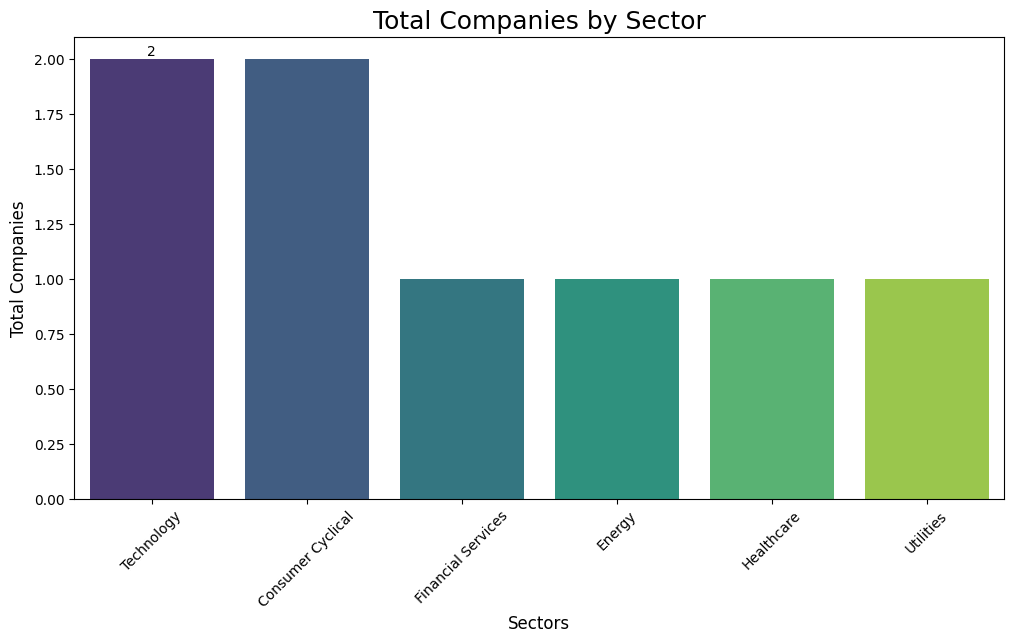

In [11]:
plt.figure(figsize=(12,6))
sec_count = sns.countplot(
    x='Sector',
    data=df_sector,
    order=df_sector['Sector'].value_counts().index,
    palette='viridis'
)

sec_count.bar_label(sec_count.containers[0], label_type='edge')
plt.xticks(rotation=45)
plt.xlabel('Sectors', size=12)
plt.ylabel('Total Companies', size=12)
plt.title('Total Companies by Sector', size=18)
plt.show()

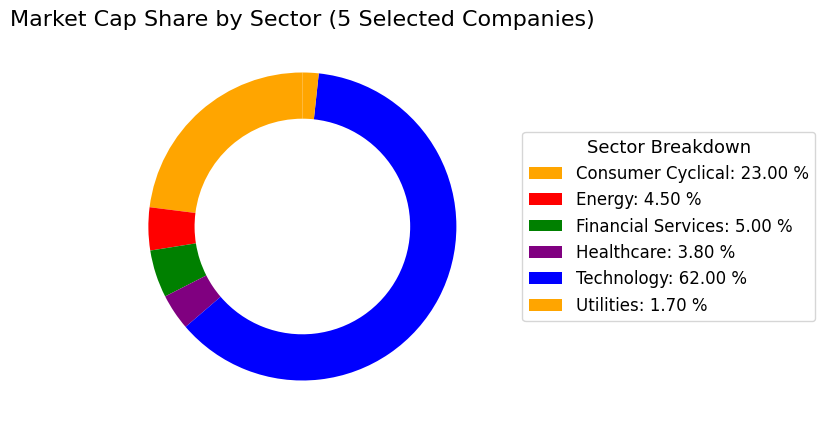

In [12]:
plt.figure(figsize=(5,5))

# Color mapping for 5 sectors
colors = ['orange', 'red', 'green', 'purple', 'blue']

secm = df_sector.groupby('Sector')['Marketcap'].sum().reset_index()
percent = 100 * (secm['Marketcap'] / secm['Marketcap'].sum())

patches, _ = plt.pie(
    secm['Marketcap'],
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.3) # To make it a donut chart if desired, or remove this line
)

# Create custom labels for the legend box
labels = [
    f"{sector}: {p:.2f} %"
    for sector, p in zip(secm['Sector'], percent)
]

#This is the box you want (just like Kaggle)
plt.legend(
    patches,
    labels,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),     # move box to the right
    fontsize=12,
    title="Sector Breakdown",        # Optional title
    title_fontsize=13,
    frameon=True                     # draws the box frame
)

plt.title('Market Cap Share by Sector (5 Selected Companies)', fontsize=16)
plt.show()

In [13]:
# Reuse already-downloaded prices from Cell 2 to avoid duplicate network calls
df.head()

,Apple,Tesla,Amazon,Visa,Microsoft
Date,,,,,
2017-01-03,29.037500,37.683498,62.580002,14.466000,79.500000
2017-01-04,29.004999,37.859001,62.299999,15.132667,80.150002
2017-01-05,29.152500,39.022499,62.299999,15.116667,81.089996
2017-01-06,29.477501,39.799500,62.840000,15.267333,82.209999
2017-01-09,29.747499,39.846001,62.639999,15.418667,81.750000


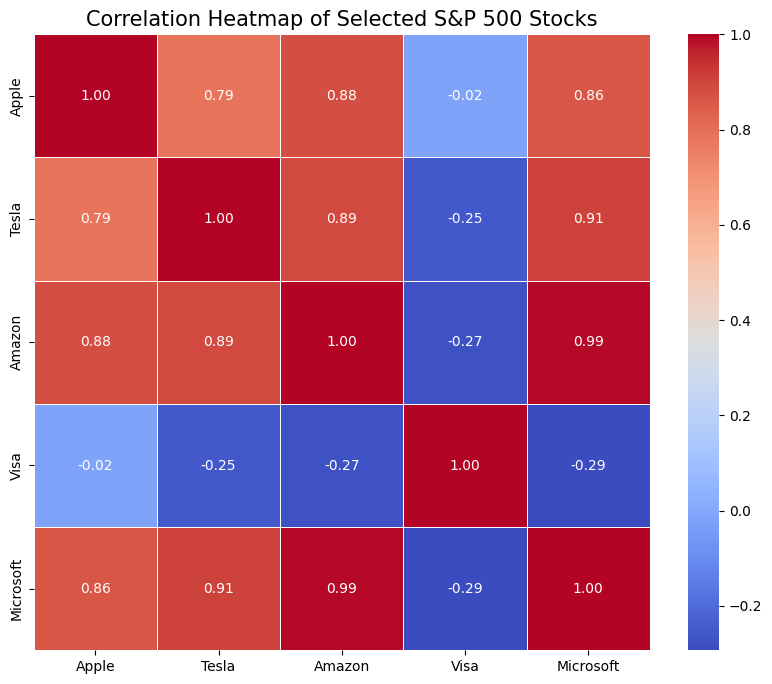

In [14]:
# Correlation of your 5 stocks
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Selected S&P 500 Stocks", fontsize=15)
plt.show()

In [4]:
# Build the ML dataset

# choose the stock you want to predict
target_stock = 'Apple'      # change to 'Tesla', 'Amazon', etc. if you want

# Make a copy with just that column
ml_df = df[[target_stock]].copy()
ml_df.rename(columns={target_stock: 'Price'}, inplace=True)

# Create target = tomorrow's price
ml_df['Target'] = ml_df['Price'].shift(-1)

# Feature engineering: past 5 daily returns
ml_df['Return_1'] = ml_df['Price'].pct_change(1)
ml_df['Return_2'] = ml_df['Price'].pct_change(2)
ml_df['Return_3'] = ml_df['Price'].pct_change(3)
ml_df['Return_4'] = ml_df['Price'].pct_change(4)
ml_df['Return_5'] = ml_df['Price'].pct_change(5)

# Drop rows with NaN created by shift / pct_change
ml_df.dropna(inplace=True)

ml_df.head()

,Price,Target,Return_1,Return_2,Return_3,Return_4,Return_5
Date,,,,,,,
2017-01-10,29.7775,29.937500,0.001009,0.010177,0.021439,0.026633,0.025484
2017-01-11,29.9375,29.812500,0.005373,0.006387,0.015605,0.026927,0.032150
2017-01-12,29.8125,29.760000,-0.004175,0.001175,0.002185,0.011365,0.022640
2017-01-13,29.7600,30.000000,-0.001761,-0.005929,-0.000588,0.000420,0.009584
2017-01-17,30.0000,29.997499,0.008065,0.006289,0.002088,0.007472,0.008488


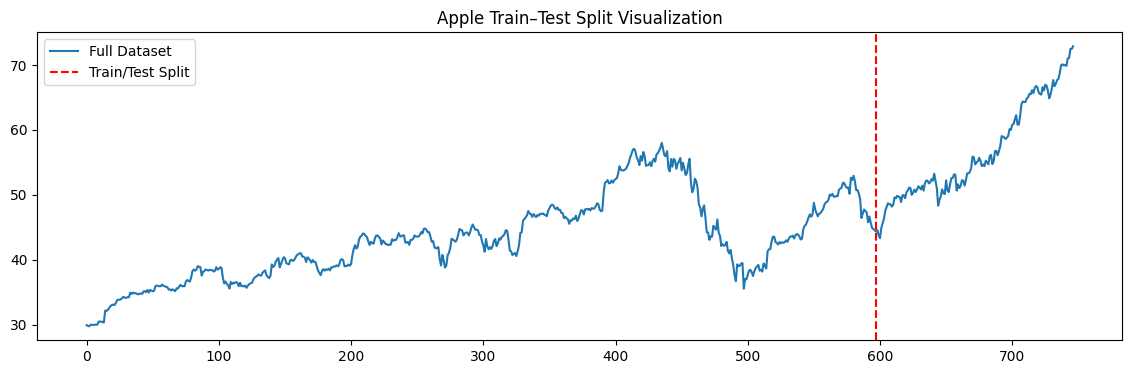

In [5]:
from sklearn.model_selection import train_test_split

X = ml_df[["Price","Return_1","Return_2","Return_3","Return_4","Return_5"]]
y = ml_df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

plt.figure(figsize=(14,4))
plt.plot(y.values, label="Full Dataset")
plt.axvline(len(y_train), color='red', linestyle='--', label="Train/Test Split")
plt.title(f"{target_stock} Train–Test Split Visualization")
plt.legend()
plt.show()

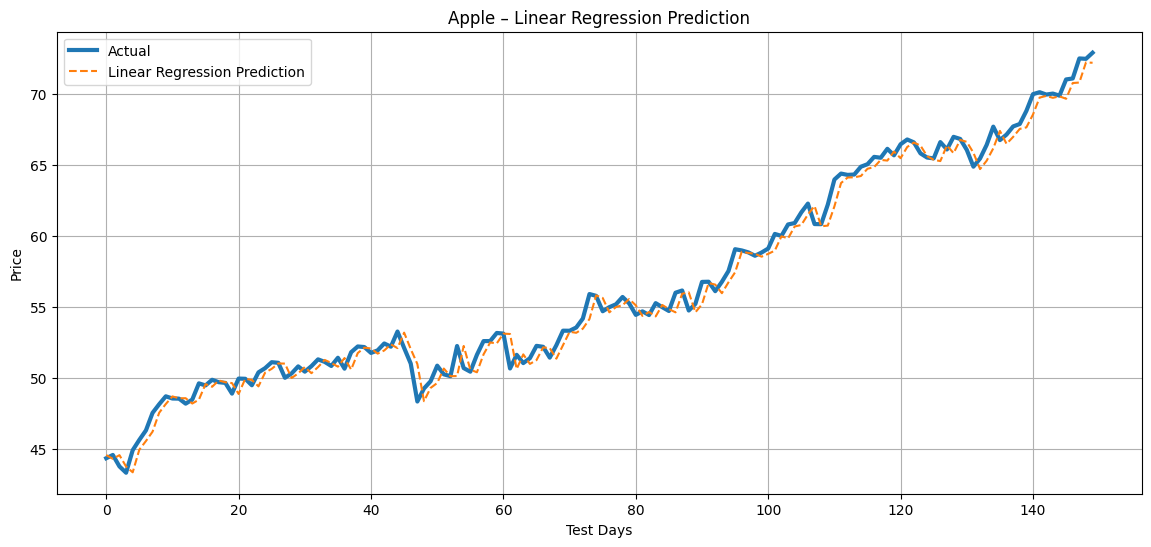

In [6]:
# Linear Regressiin model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual", linewidth=3)
plt.plot(lr_pred, label="Linear Regression Prediction", linestyle="--")
plt.title(f"{target_stock} – Linear Regression Prediction")
plt.xlabel("Test Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

Random Forest MAE: 3.703434516059028
Random Forest R^2: 0.37664633229162514


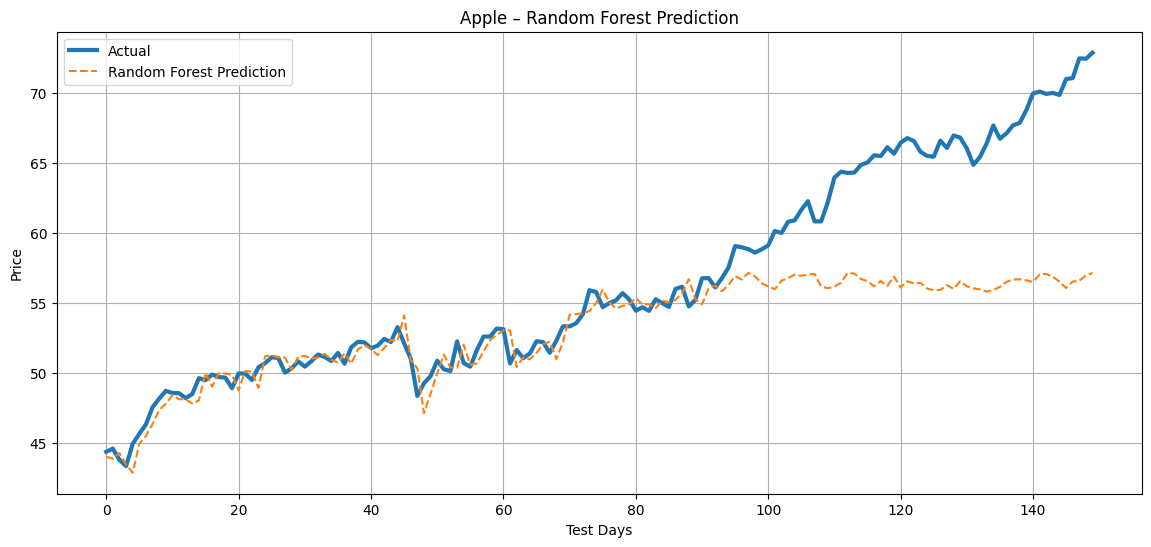

In [7]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=120,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R^2:", rf_r2)

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual", linewidth=3)
plt.plot(rf_pred, label="Random Forest Prediction", linestyle="--")
plt.title(f"{target_stock} – Random Forest Prediction")
plt.xlabel("Test Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

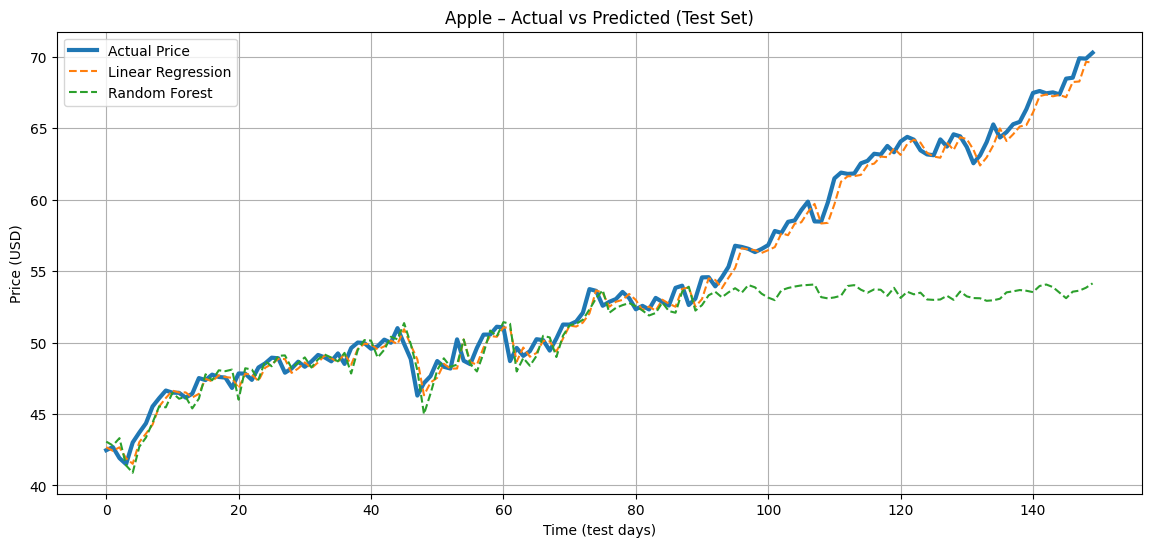

In [62]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label='Actual Price', linewidth=3)
plt.plot(lr_pred, label='Linear Regression', linestyle='--')
plt.plot(rf_pred, label='Random Forest', linestyle='--')

plt.title(f"{target_stock} – Actual vs Predicted (Test Set)")
plt.xlabel("Time (test days)")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})
results

,Model,MAE,R2 Score
0,Linear Regression,0.614452,0.988167
1,Random Forest,3.970296,0.276909


## Decision Tree Model

In this section, I use a Decision Tree Regressor to predict the next-day stock price based on the current price and the past 5 daily returns. A decision tree works by splitting the data into smaller groups based on feature values and making predictions from those splits. This model is useful because it can capture nonlinear relationships in stock price movements. I will train the model on the training dataset and then evaluate its performance using Mean Absolute Error (MAE) and R² Score.


Decision Tree MAE: 3.867962955708341
Decision Tree MSE: 36.66790551568276
Decision Tree R^2: 0.3411975407030846


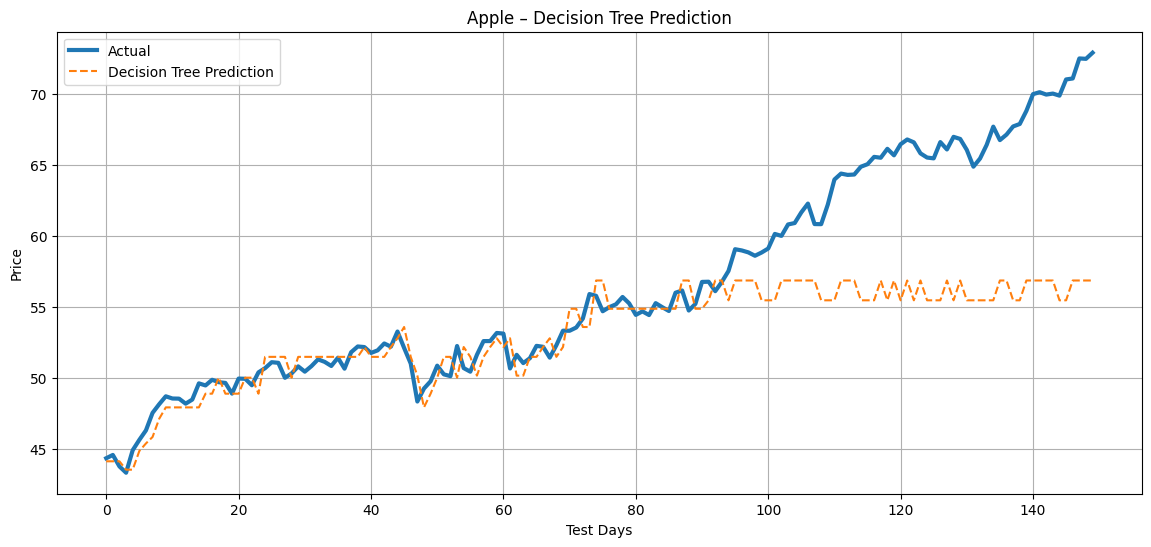

In [8]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dt = DecisionTreeRegressor(
    criterion="squared_error",   # this is the MSE-based split rule
    max_depth=5,                 # tune this
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2  = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree MSE:", dt_mse)
print("Decision Tree R^2:", dt_r2)

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual", linewidth=3)
plt.plot(dt_pred, label="Decision Tree Prediction", linestyle="--")
plt.title(f"{target_stock} – Decision Tree Prediction")
plt.xlabel("Test Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

XGBoost MAE: 3.8846180470784506
XGBoost R^2: 0.32945589394762476


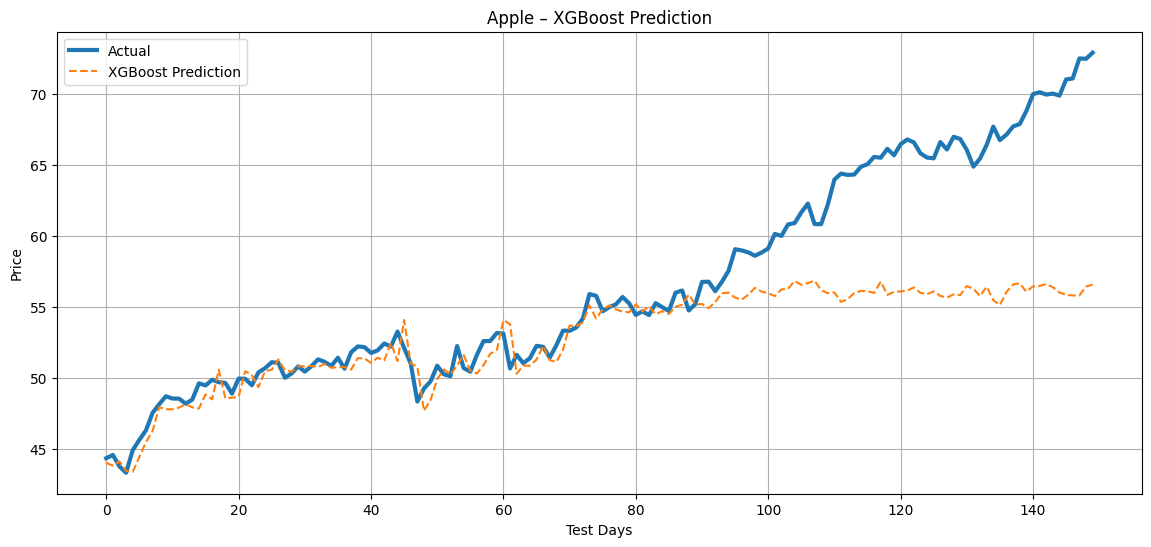

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Reuse dataset prepared earlier for all models (no duplicate feature building/split)
required_vars = ['X_train', 'X_test', 'y_train', 'y_test', 'target_stock']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Missing variables: {missing}. Run the dataset prep cells first.")

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost R^2:", xgb_r2)

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual", linewidth=3)
plt.plot(xgb_pred, label="XGBoost Prediction", linestyle="--")
plt.title(f"{target_stock} – XGBoost Prediction")
plt.xlabel("Test Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## RNN Model

This section applies a Simple RNN model to the same train/test split used by previous models. To preserve one consistent workflow, it reuses X_train, X_test, y_train, and y_test from earlier cells and only changes the learning algorithm.

RNN MAE: 5.659427973429362
RNN R^2: -0.1900881222376174


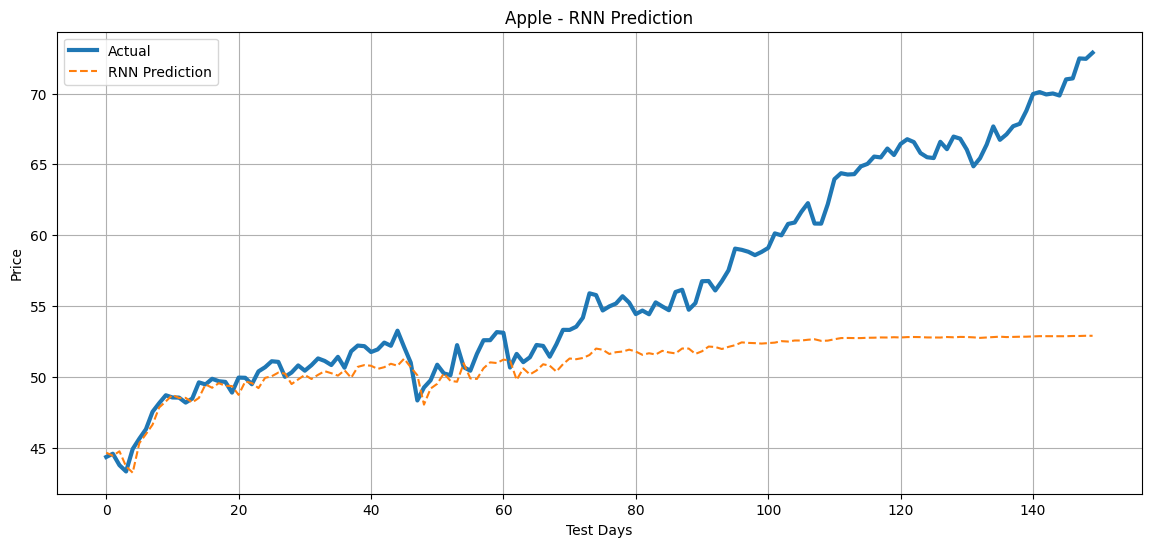

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

if not globals().get('HAS_TF', False):
    print('TensorFlow is not installed. Skipping RNN model cell.')
    rnn_pred = None
    rnn_mae = np.nan
    rnn_r2 = np.nan
else:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    tf.random.set_seed(42)

    # Reuse tabular features as a short sequence for RNN input: (samples, timesteps, features=1)
    X_train_rnn = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test_rnn = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

    rnn_model = Sequential([
        SimpleRNN(32, activation='tanh', input_shape=(X_train_rnn.shape[1], 1)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    rnn_model.compile(optimizer='adam', loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    rnn_model.fit(
        X_train_rnn,
        y_train.values,
        validation_split=0.2,
        epochs=80,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    rnn_pred = rnn_model.predict(X_test_rnn, verbose=0).ravel()
    rnn_mae = mean_absolute_error(y_test, rnn_pred)
    rnn_r2 = r2_score(y_test, rnn_pred)

    print('RNN MAE:', rnn_mae)
    print('RNN R^2:', rnn_r2)

    plt.figure(figsize=(14, 6))
    plt.plot(y_test.values, label='Actual', linewidth=3)
    plt.plot(rnn_pred, label='RNN Prediction', linestyle='--')
    plt.title(f'{target_stock} - RNN Prediction')
    plt.xlabel('Test Days')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

## LSTM Model

This section uses an LSTM model on the same split and features as the other models, so comparison stays fair and the workflow stays consistent.

LSTM MAE: 14.114540659586588
LSTM R^2: -3.579104633245577


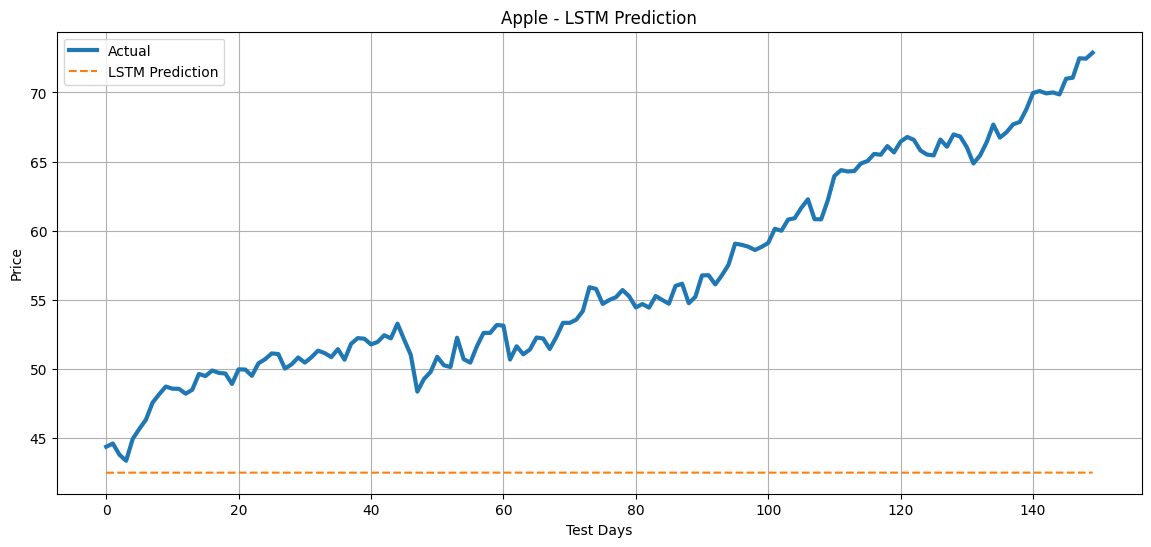

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

if not globals().get('HAS_TF', False):
    print('TensorFlow is not installed. Skipping LSTM model cell.')
    lstm_pred = None
    lstm_mae = np.nan
    lstm_r2 = np.nan
else:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    tf.random.set_seed(42)

    X_train_lstm = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test_lstm = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

    lstm_model = Sequential([
        LSTM(32, activation='tanh', input_shape=(X_train_lstm.shape[1], 1)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    lstm_model.compile(optimizer='adam', loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    lstm_model.fit(
        X_train_lstm,
        y_train.values,
        validation_split=0.2,
        epochs=80,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    lstm_pred = lstm_model.predict(X_test_lstm, verbose=0).ravel()
    lstm_mae = mean_absolute_error(y_test, lstm_pred)
    lstm_r2 = r2_score(y_test, lstm_pred)

    print('LSTM MAE:', lstm_mae)
    print('LSTM R^2:', lstm_r2)

    plt.figure(figsize=(14, 6))
    plt.plot(y_test.values, label='Actual', linewidth=3)
    plt.plot(lstm_pred, label='LSTM Prediction', linestyle='--')
    plt.title(f'{target_stock} - LSTM Prediction')
    plt.xlabel('Test Days')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

In [13]:
import pandas as pd
import numpy as np

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Decision Tree",
        "XGBoost",
        "RNN",
        "LSTM"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        dt_mae,
        xgb_mae,
        rnn_mae if 'rnn_mae' in globals() else np.nan,
        lstm_mae if 'lstm_mae' in globals() else np.nan
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        dt_r2,
        xgb_r2,
        rnn_r2 if 'rnn_r2' in globals() else np.nan,
        lstm_r2 if 'lstm_r2' in globals() else np.nan
    ]
})

results

,Model,MAE,R2 Score
0,Linear Regression,0.640737,0.987722
1,Random Forest,3.703435,0.376646
2,Decision Tree,3.867963,0.341198
3,XGBoost,3.884618,0.329456
4,RNN,5.577606,-0.193556
5,LSTM,14.086205,-3.564751
